# 02A Maximum Likelihood: Principles and Geometry

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/06-Econometrics/02A_MLE_Principles_and_Geometry.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=06-Econometrics/02A_MLE_Principles_and_Geometry.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# === Environment Setup ===
import random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.optimize import minimize
from scipy.stats import norm, chi2
import statsmodels.api as sm
from IPython.display import Image, display, Markdown

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (11, 7), 'figure.dpi': 130})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=120, precision=4)


## The Lens: Likelihood as Geometry
**What economic problem are we solving?**
We observe outcomes but not the parameters that generated them. Maximum likelihood turns this into a geometric search: which parameter values make the observed data most probable?

**Why this method?**
The log-likelihood surface encodes both fit and uncertainty. Its slope (the score) and curvature (information) tell us how the data pin down parameters and how precise our estimates will be.



**Economic question.** In *02A Maximum Likelihood: Principles and Geometry*, what must remain economically invariant when the computational representation changes? The computational task only has economic meaning after the estimand and identifying assumptions are explicit. Ask what variation identifies the parameter, which observations act as the comparison group, and what data-generating process would make the estimator fail. A good empirical workflow pairs the point estimate with diagnostics, uncertainty, and at least one falsification or sensitivity check so that precision is not confused with identification.

### Learning Objectives
* **Define** likelihood and log-likelihood functions for common models.
* **Interpret** the score vector and Fisher information as geometric objects.
* **Apply** these ideas to a simple Bernoulli example.

### Prerequisites
* **Probability:** PDFs, CDFs, and the Normal distribution.
* **Calculus:** Derivatives and optimization basics.
* **`06-Econometrics/01_Linear_Model_and_OLS.ipynb`**: Regression foundations.


> **Learning path:** Building on [`01_Linear_Model_and_OLS.ipynb`](01_Linear_Model_and_OLS.ipynb); next continue with [`02B_MLE_Optimization_and_Applications.ipynb`](02B_MLE_Optimization_and_Applications.ipynb).


### Table of Contents
1. [Introduction: The Principle of Maximum Likelihood](#1-introduction-the-principle-of-maximum-likelihood)
2. [The Likelihood and Log-Likelihood Functions](#the-lens-likelihood-as-geometry)
- [The Geometry of the Log-Likelihood Function](#the-geometry-of-the-log-likelihood-function)
   - [The Score Vector](#the-score-vector)
   - [The Fisher Information Matrix](#the-fisher-information-matrix)
4. [Summary](#summary)


## Implementation Note

The reusable `MLEstimator` implementation is introduced in **`02B_MLE_Optimization_and_Applications.ipynb`**, along with numerical optimization and applied examples.


<a id='intro'></a>
## 1. Introduction: The Principle of Maximum Likelihood

**Maximum Likelihood Estimation (MLE)** is the gold standard for parametric estimation. It asks a simple but powerful question:

> *Given the data we have observed, what values of the parameters would make this data the **most probable**?*

Assume we have data $\mathbf{y} = (y_1, ..., y_n)$ drawn from a probability distribution $f(y; \theta)$.
The **Likelihood Function** $L(\theta | \mathbf{y})$ is simply the joint probability of the data, viewed as a function of $\theta$:
$$ L(\theta | \mathbf{y}) = \prod_{i=1}^n f(y_i; \theta) $$

We maximize the **Log-Likelihood** $\mathcal{L}(\theta)$ because sums are easier to differentiate than products:
$$ \mathcal{L}(\theta) = \ln L(\theta) = \sum_{i=1}^n \ln f(y_i; \theta) $$

**Dimension notes:** the data vector is $\mathbf{y} = (y_1, \dots, y_n)$ with scalar observations $y_i \in \mathbb{R}$ drawn iid from $f(y; \theta)$; the parameter lives in $\theta \in \Theta \subseteq \mathbb{R}^p$; both $L(\theta \mid \mathbf{y})$ and the log-likelihood $\mathcal{L}(\theta)$ are scalar-valued functions on $\Theta$.

## The Geometry of the Log-Likelihood Function

Under regularity conditions the log-likelihood is locally concave around its maximizer, so maximum likelihood is a peak-climbing problem. How sharply the peak is curved determines how precisely the data identify the parameter: a flat ridge means many parameter values fit almost equally well. That curvature is the Fisher information, quantified below.
## The Score Vector

The score is the gradient of the log-likelihood with respect to the parameter vector. By the first-order condition the score vanishes at the maximum likelihood estimate, which is why Newton-type optimizers iterate toward a zero of the score. Under correct specification the score has expectation zero at the truth, and its outer product is the classical sandwich variance estimator.
## The Fisher Information Matrix

The Fisher information is the negative expected Hessian of the log-likelihood. It bounds the achievable precision of any unbiased estimator through the Cramér–Rao inequality, and the asymptotic variance of the maximum likelihood estimator is its inverse. Information therefore unifies two intuitions: curvature of the likelihood and statistical precision are the same statement.


### Example: MLE for a Bernoulli Process (Coin Flip)

Suppose we flip a coin 10 times and get 8 heads. What is the probability $p$ of heads?
The likelihood is $L(p) = p^8 (1-p)^2$. The log-likelihood is $8 \ln(p) + 2 \ln(1-p)$.
Let's visualize this function.


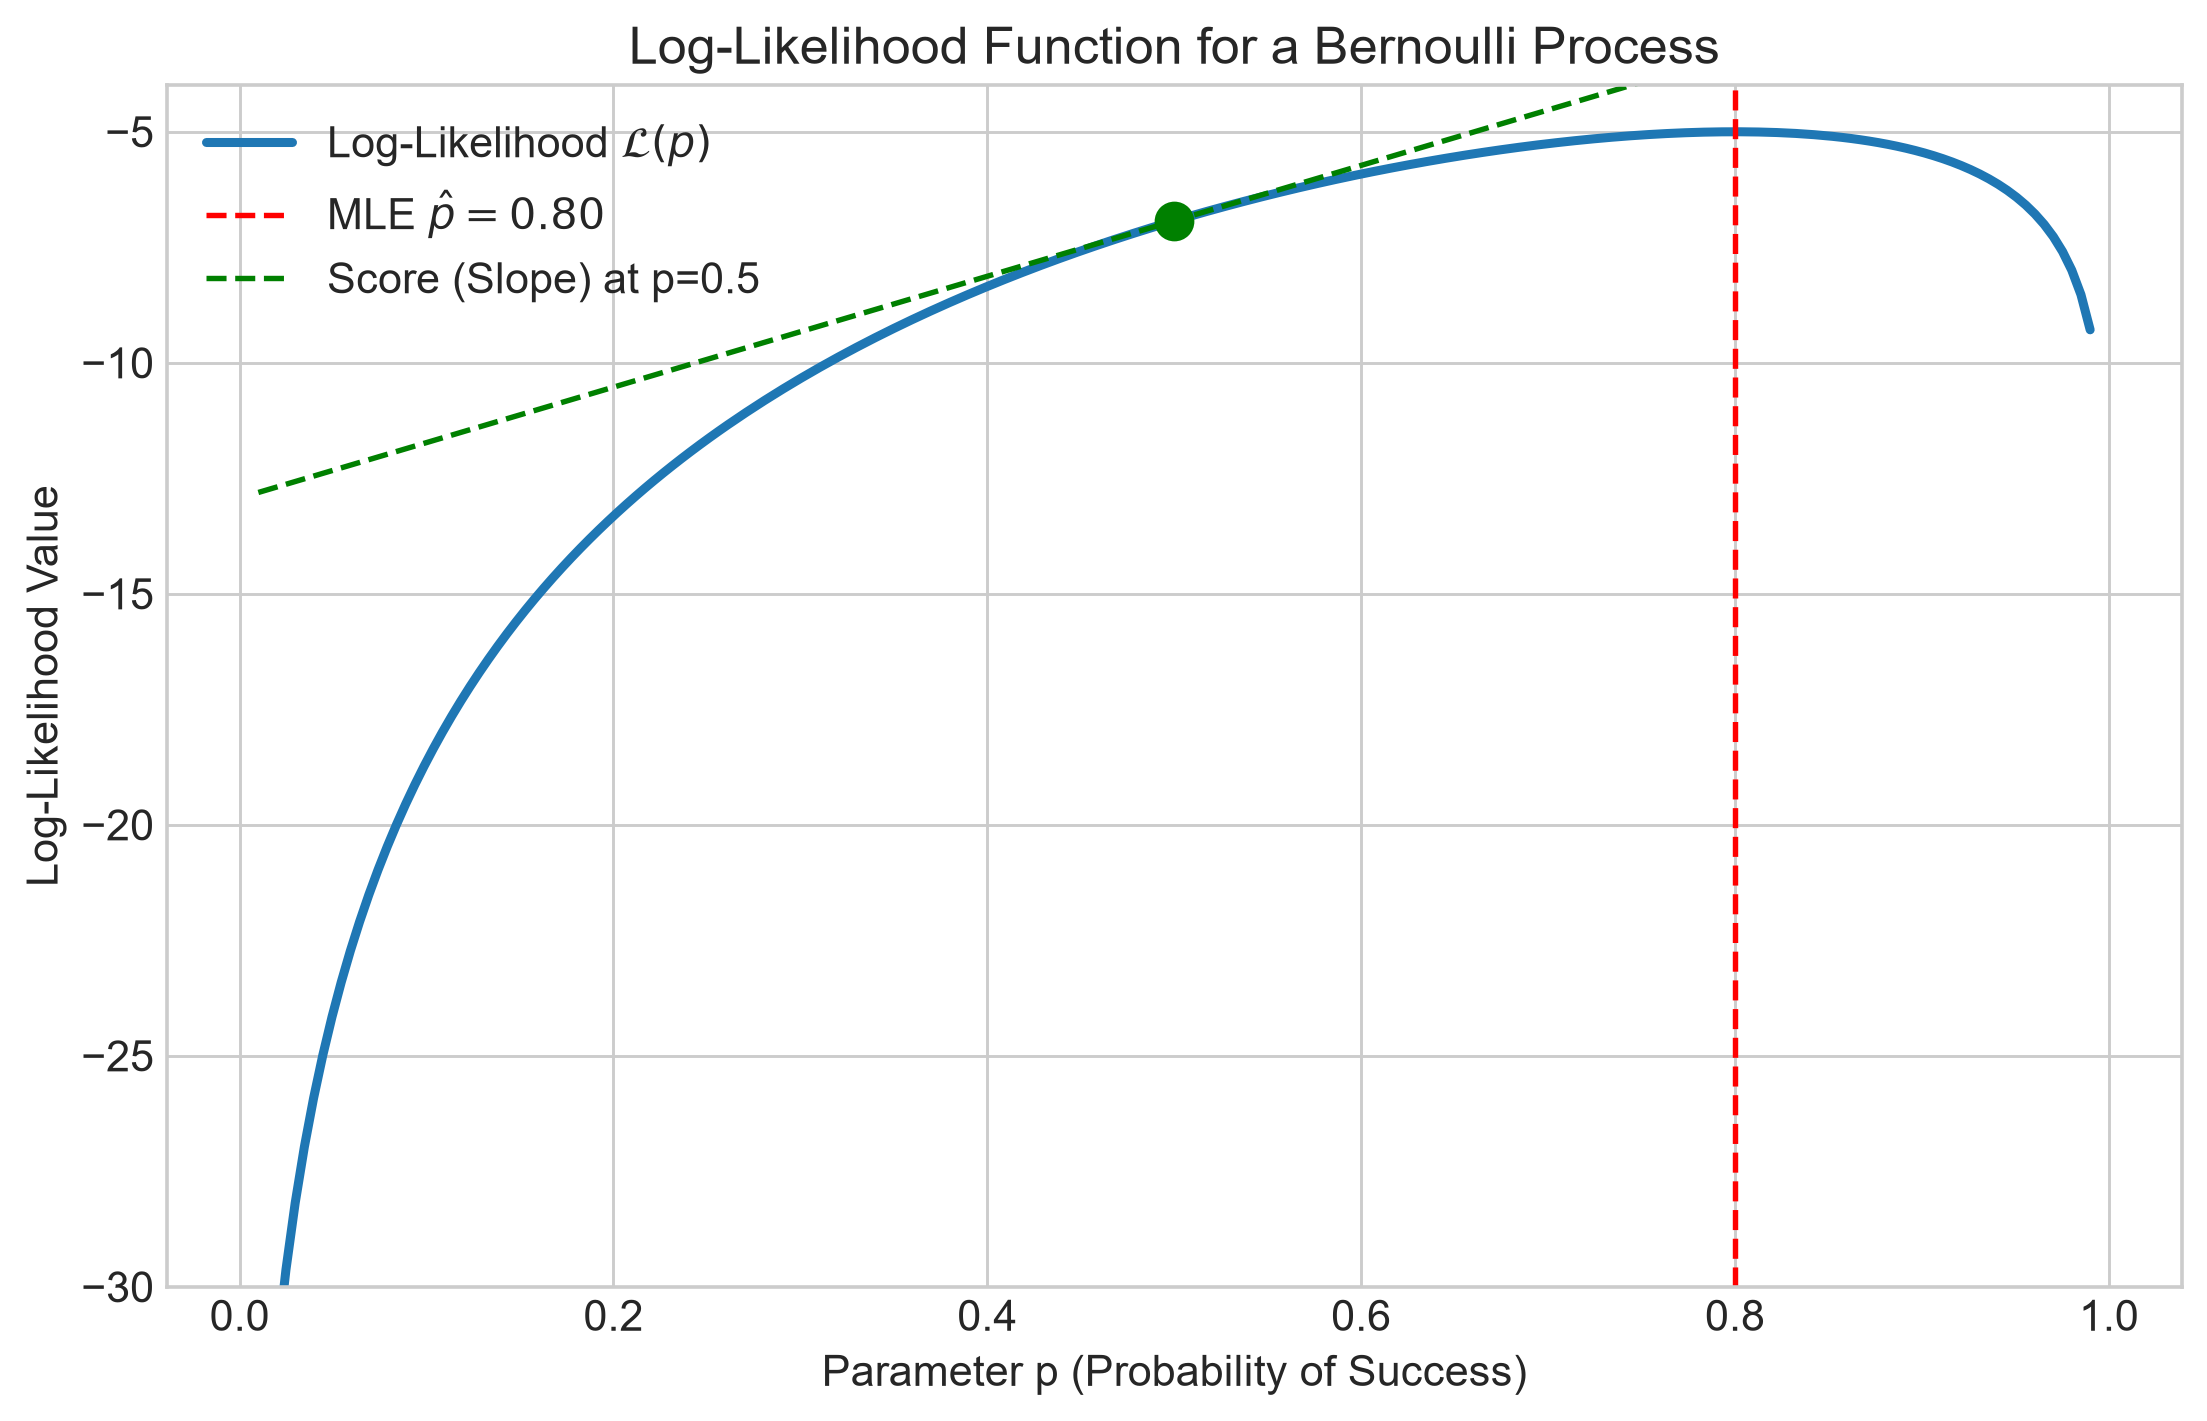

In [2]:
# Simple example: MLE for the probability 'p' of a Bernoulli trial
n_heads = 8
n_tails = 2
log_likelihood = lambda p: n_heads * np.log(p) + n_tails * np.log(1-p)

p_grid = np.linspace(0.01, 0.99, 200)
ll_vals = log_likelihood(p_grid)
mle_p = n_heads / (n_heads + n_tails)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p_grid, ll_vals, lw=2.5, label=r'Log-Likelihood $\mathcal{L}(p)$')
ax.axvline(mle_p, color='r', ls='--', label=rf'MLE $\hat{{p}}={mle_p:.2f}$')

# Illustrate the Score (slope) at a test point
p_test = 0.5
ll_test = log_likelihood(p_test)
score_test = (n_heads/p_test) - (n_tails/(1-p_test))
ax.plot(p_test, ll_test, 'go', ms=10)
ax.plot(p_grid, ll_test + score_test * (p_grid - p_test), 'g--', label='Score (Slope) at p=0.5')

ax.set_title('Log-Likelihood Function for a Bernoulli Process')
ax.set_xlabel('Parameter p (Probability of Success)')
ax.set_ylabel('Log-Likelihood Value')
ax.set_ylim(-30, -4)
ax.legend(); plt.show()


> **Common Pitfalls in This Lecture**
>
> - **Likelihood underflow.** Multiplying hundreds of densities underflows to exactly `0.0` in floating point. Maximize the log-likelihood (sum of logs) — same argmax, numerically sane. This is why every serious routine works in logs.
> - **Boundary 'optima'.** MLE need not exist in the interior: variance parameters can drift to zero, mixture weights to degeneracy. A flat or boundary optimum defeats gradient checks; inspect gradients and parameter bounds rather than trusting the reported maximum.

## Exercises

**1. Mechanism and assumptions (Conceptual):** Define the estimand in **02A Maximum Likelihood: Principles and Geometry**, list the identifying assumptions, and give a concrete data-generating process that violates one assumption while leaving the others intact.

**2. Reproduce and diagnose (Applied):** Implement or reproduce the estimator using the material on Implementation Note, 1. Introduction: The Principle of Maximum Likelihood. Report uncertainty and at least two diagnostics; then compare with an alternative specification that targets the same estimand.

**3. Robust extension (Challenge):** Run a Monte Carlo or sensitivity exercise that varies the most fragile identifying condition. Quantify bias/coverage or the range of estimates and state what evidence would change your substantive conclusion.

**3b. Failure analysis (Challenge):** The probit log-likelihood is nearly flat in one coefficient's direction and its standard error is enormous. Diagnose quasi-complete separation (a regressor almost perfectly predicting the outcome), repair with penalized MLE or dropping/combining categories, and show the flatness with a profile likelihood slice.

<details>
<summary>Solution guidance</summary>

**Lesson-specific checkpoints:** Name the estimand and identifying variation, report uncertainty in the scale of the outcome, and run the diagnostic/falsification implied by this design (for example balance, residual behavior, continuity, instrument strength, or alternative specification). A precise estimate is not evidence of identification by itself. See [`docs/ASSESSMENT_GUIDE.md`](../docs/ASSESSMENT_GUIDE.md).

</details>


## Key Equations

- **Likelihood:** $L(\theta;y)=\prod_i f(y_i\mid\theta)$.
- **Log-likelihood:** $\ell(\theta)=\sum_i \log f(y_i\mid\theta)$.
- **Score:** $s(\theta)=\nabla_\theta\ell(\theta)$.
- **Observed information:** $-\nabla_\theta^2\ell(\theta)$.
- **Asymptotic normality:** under regularity conditions, $\sqrt{n}(\hat\theta-\theta_0)$ converges to a centered normal distribution with covariance equal to the inverse Fisher information.


# Summary

This part introduced the likelihood principle and the geometry of log-likelihoods that underpin maximum likelihood estimation.


## References & Further Reading

- Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press.
- Angrist, J. D. & Pischke, J.-S. (2009). *Mostly Harmless Econometrics*. Princeton University Press.
- Imbens, G. W. & Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge University Press.
